In [1]:
from csv import DictReader

with open('properties_master.csv', 'r') as csv_file:
    reader = DictReader(csv_file)
    rows = [r for r in reader]
csv_file.close()

compounds = []
for r in rows:
    if r['properties.flash_point.value'] != '-':
        compounds.append(r)

In [2]:
from sklearn.model_selection import train_test_split

smiles = [c['canonical_smiles'] for c in compounds]
targets = [[float(c['properties.flash_point.value'])] for c in compounds]

smiles_train, smiles_test, targets_train, targets_test = train_test_split(
    smiles, targets, test_size=0.2, random_state=24
)

In [3]:
from ecnet.datasets import QSPRDataset

ds_train = QSPRDataset(smiles_train, targets_train, backend='alvadesc')
ds_test = QSPRDataset(smiles_test, targets_test, backend='alvadesc')

In [4]:
from ecnet.tasks import select_rfr

desc_idx, desc_imp = select_rfr(ds_train, total_importance=0.999, n_estimators=100, n_jobs=4)
ds_train.set_desc_index(desc_idx)
ds_test.set_desc_index(desc_idx)
print(ds_train.desc_names[:5], desc_imp[:5])
print(ds_train.desc_vals.shape, ds_test.desc_vals.shape)
with open('fp_desc.txt', 'w') as txt_file:
    txt_file.writelines([str(i) + '\n' for i in desc_idx])
txt_file.close()

['SpAD_B(s)', 'SpAbs_B(s)', 'GMTIV', 'HyWi_B(s)', 'SpPos_B(s)'] [0.4821425488037827, 0.06191921964166108, 0.03744303465254121, 0.032858315723360246, 0.018290901135174613]
torch.Size([204, 1196]) torch.Size([51, 1196])


In [5]:
from ecnet import ECNet

net = ECNet(ds_train.desc_vals.shape[1], ds_train.target_vals.shape[1], 128, 1)
loss_train, loss_valid = net.fit(
    dataset=ds_train,
    batch_size=8,
    epochs=1024,
    valid_size=0.2,
    shuffle=True,
    lr=0.001,
    patience=64,
    verbose=10
)

Epoch: 0 | Train loss: 3516.238610764954 | Valid loss: 9223372036854775807
Epoch: 10 | Train loss: 509.37637179322036 | Valid loss: 657.1055297851562
Epoch: 20 | Train loss: 334.3959656814856 | Valid loss: 298.04058837890625
Epoch: 30 | Train loss: 256.03482186721146 | Valid loss: 344.0760192871094
Epoch: 40 | Train loss: 222.6992150055119 | Valid loss: 241.8916473388672
Epoch: 50 | Train loss: 201.089506901115 | Valid loss: 179.86282348632812
Epoch: 60 | Train loss: 294.80352783203125 | Valid loss: 447.8314208984375
Epoch: 70 | Train loss: 151.38364602305407 | Valid loss: 187.8300018310547
Epoch: 80 | Train loss: 131.07031450096085 | Valid loss: 224.13209533691406
Epoch: 90 | Train loss: 141.70264679376334 | Valid loss: 146.23497009277344
Epoch: 100 | Train loss: 224.29806970233565 | Valid loss: 217.9688720703125
Epoch: 110 | Train loss: 107.43072163400474 | Valid loss: 122.68315124511719
Epoch: 120 | Train loss: 122.94333896753979 | Valid loss: 235.82948303222656
Epoch: 130 | Train l

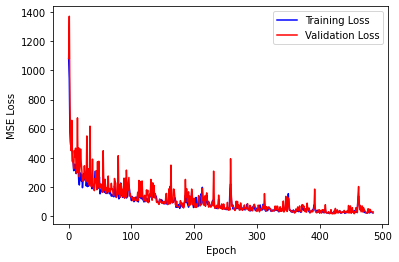

In [6]:
from matplotlib import pyplot as plt

loss_train = loss_train[5:]
loss_valid = loss_valid[5:]
epochs = [i for i in range(len(loss_train))]

plt.clf()
plt.plot(epochs, loss_train, label='Training Loss', color='blue')
plt.plot(epochs, loss_valid, label='Validation Loss', color='red')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend(loc='upper right')
plt.show()

In [7]:
from sklearn.metrics import median_absolute_error, r2_score

results_train = net.forward(ds_train.desc_vals).detach().numpy()
targets_train = ds_train.target_vals.detach().numpy()
results_test = net.forward(ds_test.desc_vals).detach().numpy()
targets_test = ds_test.target_vals.detach().numpy()

mae_train = median_absolute_error(targets_train, results_train)
mae_test = median_absolute_error(targets_test, results_test)
r2_train = r2_score(targets_train, results_train)
r2_test = r2_score(targets_test, results_test)

print(f'Train: {mae_train}, {r2_train}')
print(f'Test: {mae_test}, {r2_test}')

Train: 2.835874557495117, 0.9914188745272419
Test: 6.1959381103515625, 0.9189104531764084


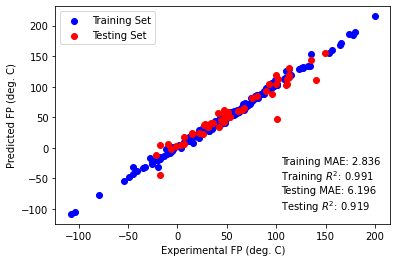

In [8]:
from matplotlib.offsetbox import AnchoredText

plt.clf()
plt.scatter(targets_train, results_train, label='Training Set', color='blue')
plt.scatter(targets_test, results_test, label='Testing Set', color='red')
plt.legend(loc='upper left')
string = 'Training MAE: {:.3f}'.format(mae_train)
string += '\nTraining $R^2$: {:.3f}'.format(r2_train)
string += '\nTesting MAE: {:.3f}'.format(mae_test)
string += '\nTesting $R^2$: {:.3f}'.format(r2_test)
text_box = AnchoredText(string, frameon=True, loc=4, pad=0.5)
plt.setp(text_box.patch, facecolor='white', edgecolor='w')
plt.gca().add_artist(text_box)
plt.xlabel('Experimental FP (deg. C)')
plt.ylabel('Predicted FP (deg. C)')
plt.show()

In [9]:
net.save('fp.pt')